<a href="https://colab.research.google.com/github/PavanPk1/MyPractice_Colab_notebooks/blob/main/central_limit_theorem_proof.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random
random.seed = 5

from matplotlib import style
style.use('ggplot')

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('adult_dataset.csv')
df.head(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,?,227026,HS-grad,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


In [4]:
df.shape

(48842, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


# Population Distribution

<Axes: xlabel='age', ylabel='Density'>

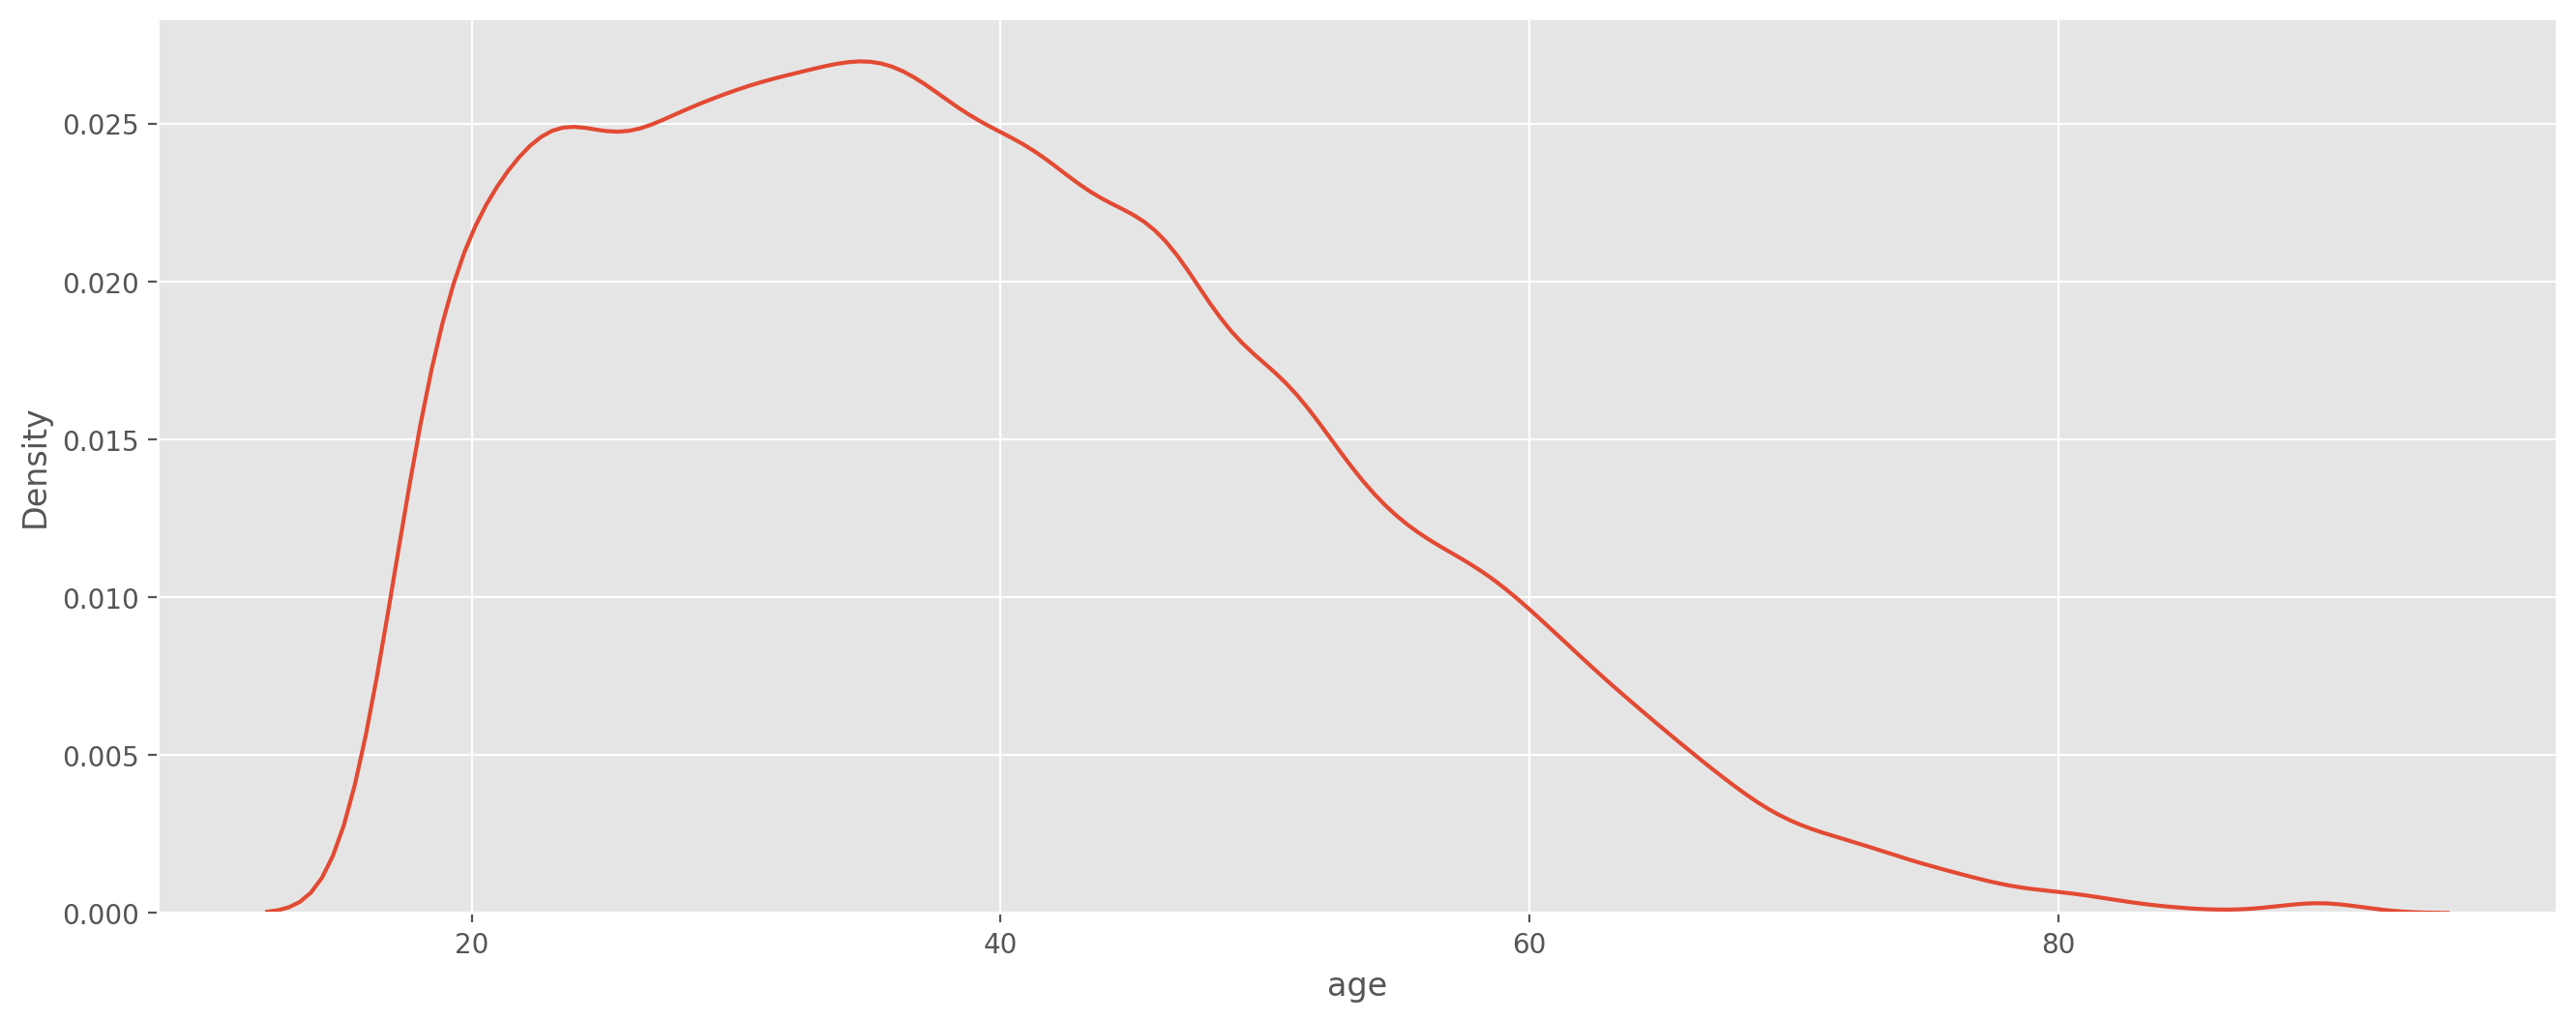

In [6]:
plt.figure(figsize = (16,6), dpi = 200)
sns.distplot(df.age, hist = False)

# Creating Samples and Calculating Sample Means

In [7]:
print('Number of observations : ', df.age.shape)

Number of observations :  (48842,)


In [8]:
sample = random.sample(range(0,48842), 10)
sample

[4198, 38455, 27789, 19361, 11174, 14089, 7548, 34764, 1622, 17506]

In [9]:
df.iloc[sample, 0]

,age
4198,46
38455,41
27789,39
19361,40
11174,24
14089,27
7548,41
34764,28
1622,47
17506,29


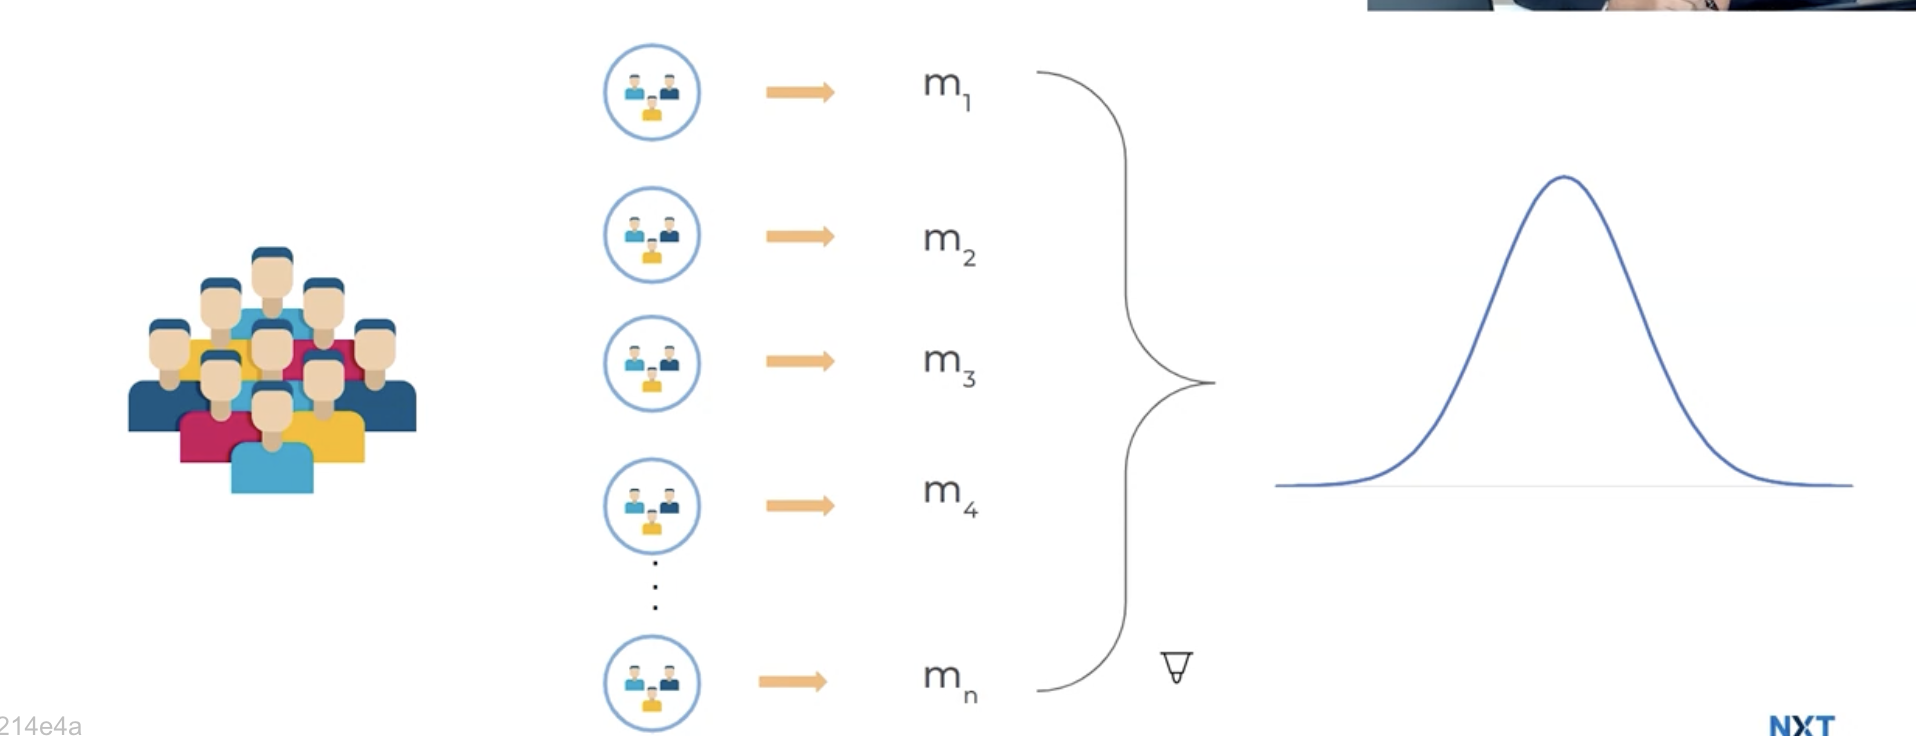

Let have 1000 samples having sample size of 100

In [11]:
sample_size = 100
no_of_samples = 1000
sample_means = []
for i in range(no_of_samples):
    indexes = random.sample(range(0,48842), sample_size)
    sample = df.iloc[indexes, 0]
    sample_means.append(sample.mean())

# Distribution Of Sample Means

<Axes: ylabel='Density'>

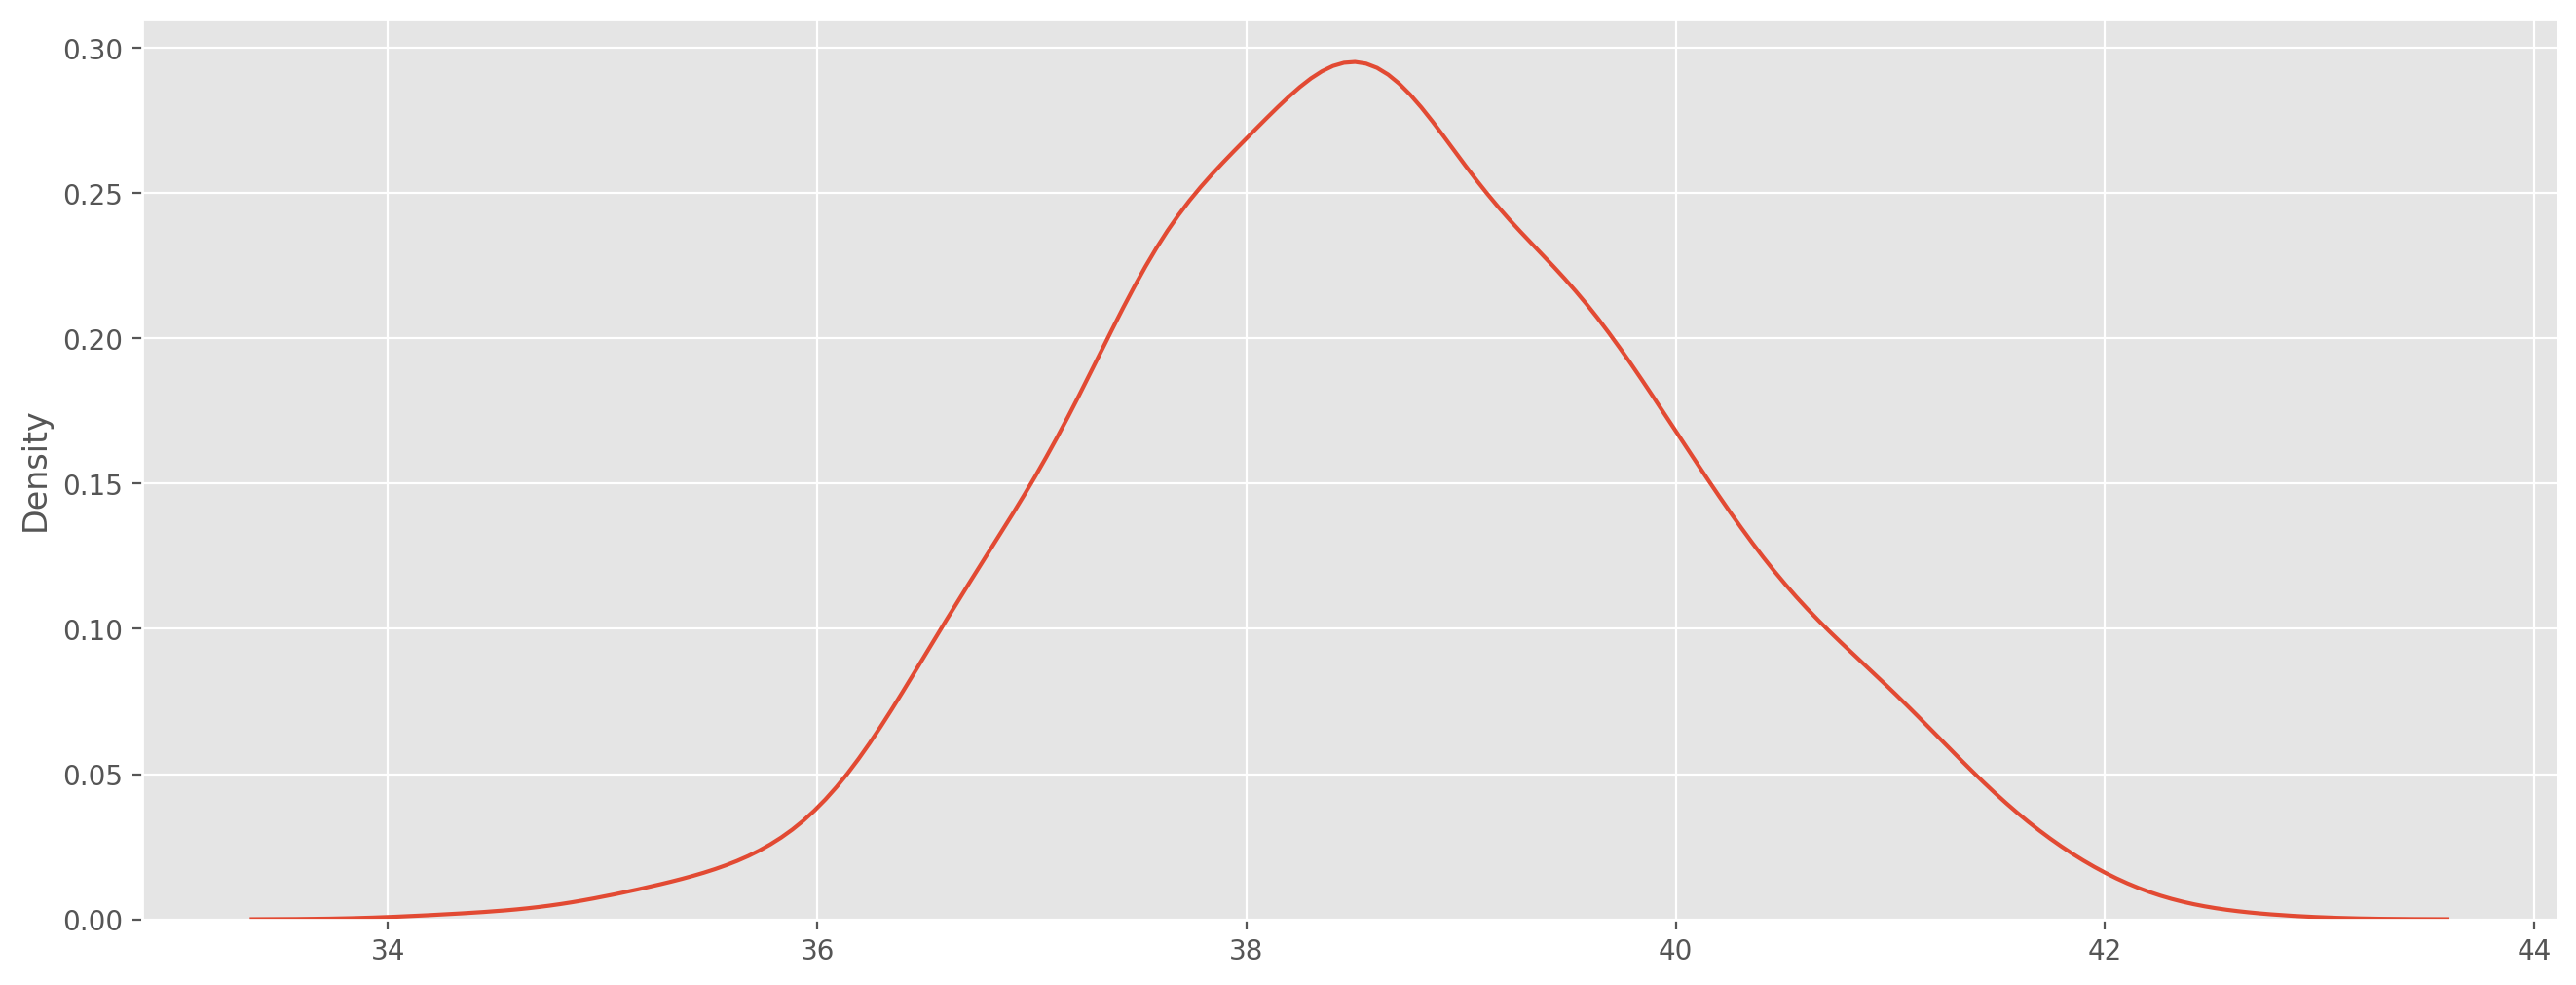

In [12]:
plt.figure(figsize = (16,6), dpi = 200)
sns.distplot(sample_means, hist = False)

Mean and Standard Deviation of Sample Means
Formula for Sample Mean:
X = μ
Where:
X = Mean of the sample means.
μ = Population mean.
Formula for Standard Deviation of Sample Means (Standard Error):
 σs  = σ /  √n
Where:
σs = Standard deviation of sample means.
σ = Population standard deviation.
n = Sample size.


## Mean Of Sample Means

In [13]:
# Mean of sample means is approximately equal to population mean
mean_of_samples = np.mean(sample_means)
population_mean = df.age.mean()

print('Mean of sample means : ', mean_of_samples)
print('Mean of population   : ', population_mean)

Mean of sample means :  38.64259
Mean of population   :  38.64358543876172


## Standard Deviation Of Sample Means

In [14]:
# Standard deviation of samples is approximately equal to (std of population/sqrt of sample size)
std_of_samples = np.std(sample_means)
std_of_population = df.age.std()
calculated_std = std_of_population / np.sqrt(sample_size)

print('Calculated standard deviation os samples : ', calculated_std)
print('Actual standard deviation of samples     : ', std_of_samples)

Calculated standard deviation os samples :  1.371050993444322
Actual standard deviation of samples     :  1.3325991114735145


## Effect of sample size on standard deviation of sample means

In [19]:
sample_size = 2 # CLT does not hold true as sample size is < 30
no_of_samples = 1000
sample_means = []

for i in range(no_of_samples):
    indexes = random.sample(range(0,48842), sample_size)
    sample = df.iloc[indexes, 0]
    sample_means.append(sample.mean())

In [20]:
sample_means[:5]

[np.float64(40.5),
 np.float64(38.5),
 np.float64(37.5),
 np.float64(59.0),
 np.float64(36.5)]

In [21]:
# Standard deviation of samples is approximately equal to (std of population/sqrt of sample size)
std_of_samples = np.std(sample_means)
std_of_population = df.age.std()
calculated_std = std_of_population / np.sqrt(sample_size)

print('Calculated standard deviation of samples : ', calculated_std)
print('Actual standard deviation of samples     : ', std_of_samples)

Calculated standard deviation of samples :  9.694794548170327
Actual standard deviation of samples     :  9.717213129287636


So we can say that increase/decrease in sample size it will effect the standard deviation of sample

<Axes: ylabel='Density'>

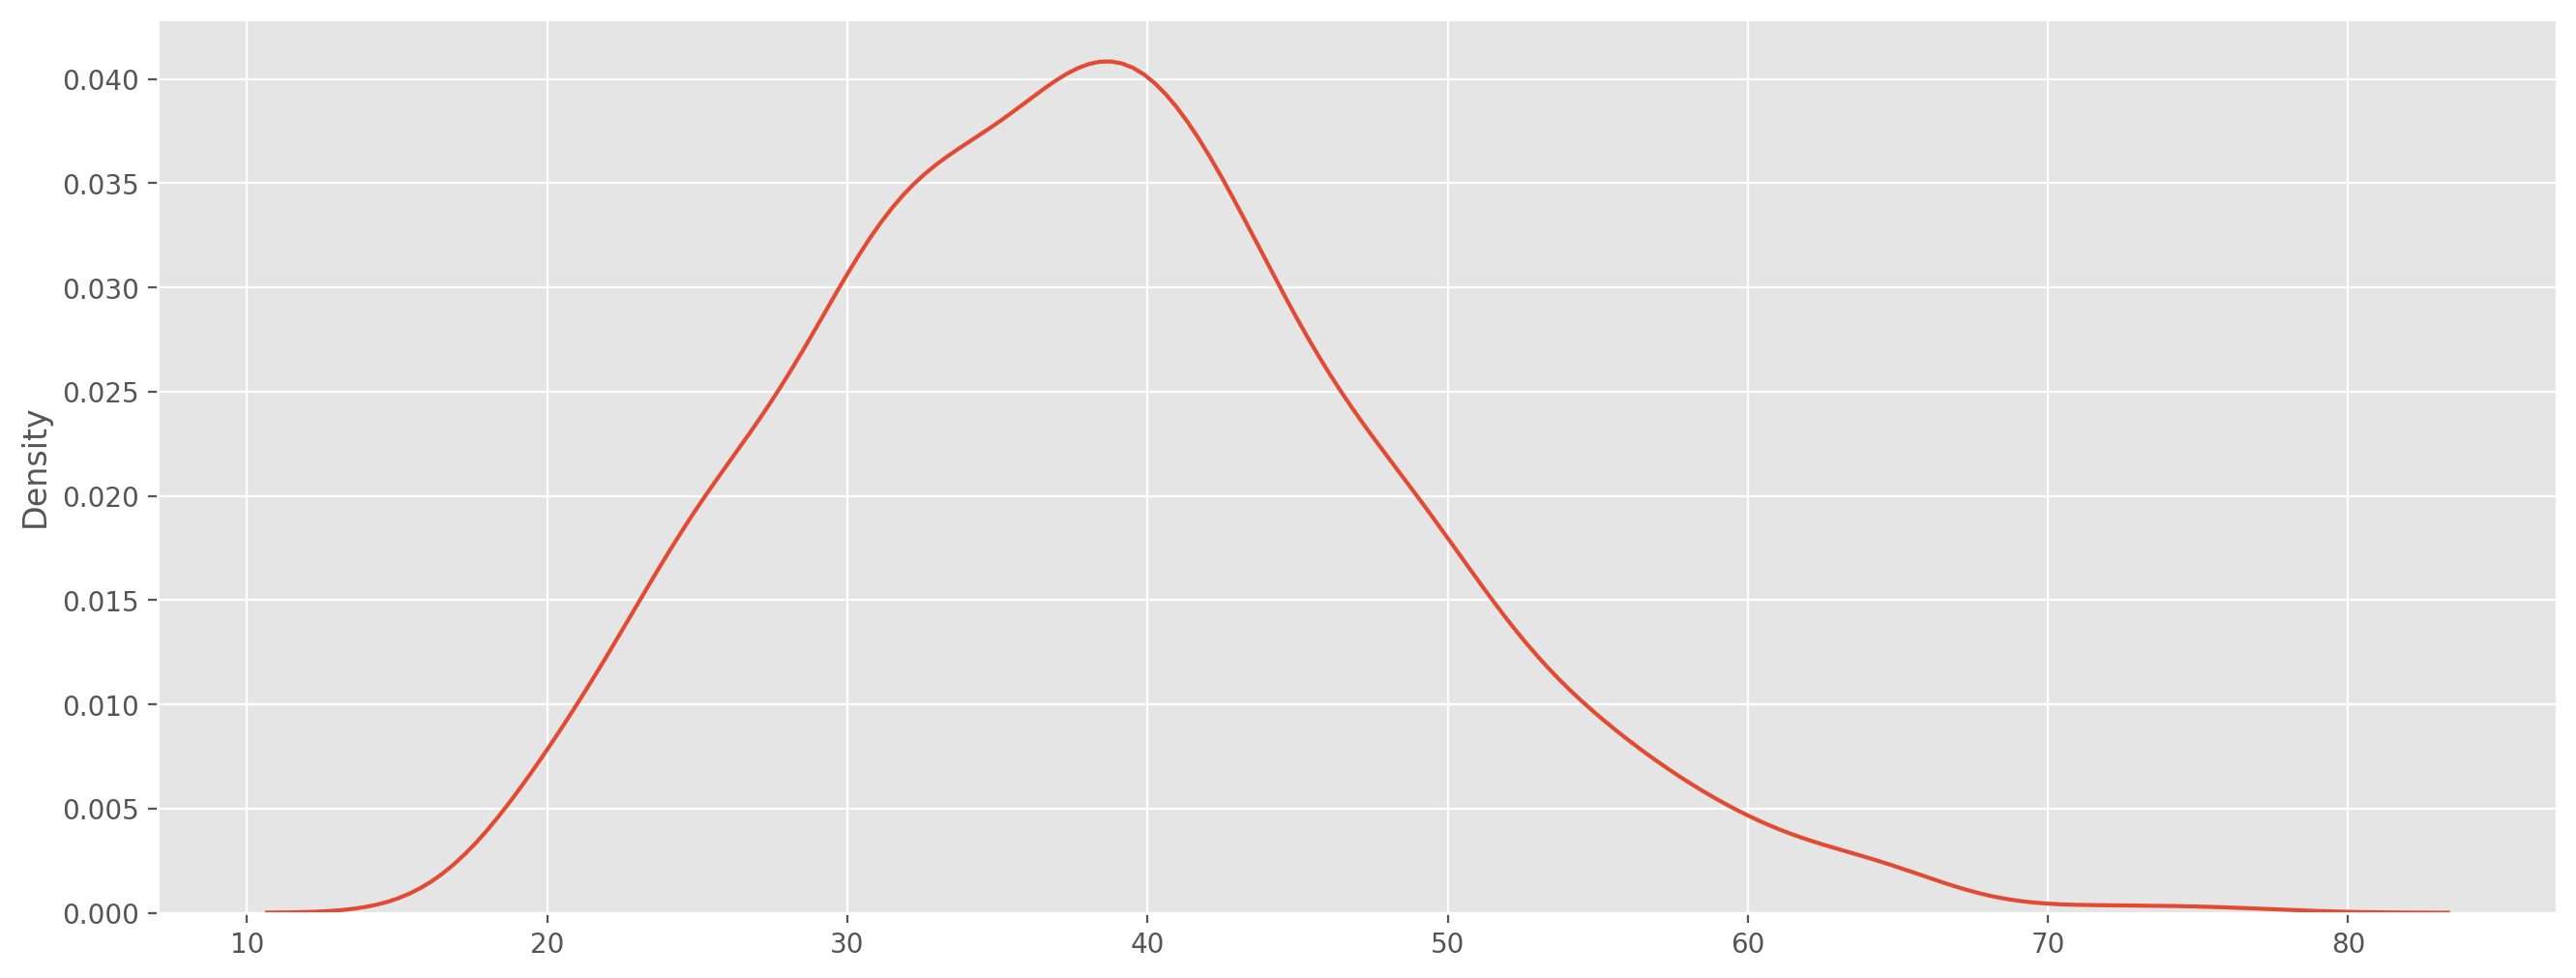

In [22]:
plt.figure(figsize = (16,6), dpi = 200)
sns.distplot(sample_means, hist = False)